# XGBoost + SHAP
## Goal
- Train XGBoost model and compare against Random Forest baseline
- Add probability calibration to ensure reliable probability outputs
- Run SHAP analysis to explain model predictions
- Generate SHAP summary plot for blog post and dashboard

## Input
- aus_gp_features.csv
- rf_model.pkl (random forest model - baseline)

## Output
- Calibrated XGBoost model
- SHAP summary plot
- Final probability outputs per driver

## Why XGBoost?
Random Forest beat Logistic Regression (0.98 vs 0.96 AUC).
XGBoost builds trees sequentially where each tree learns from the mistakes of the previous one, making it
more powerful than Random Forest's parallel tree approach.

## Why Calibration?
Raw model probabilities are often overconfident or underconfident. Calibration adjusts them to be statistically reliable — if the model
says 70% probability, the driver should podium roughly 70% of the time.

# Core Libraries 

In [18]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import shap
import matplotlib.pyplot as plt
import pickle
%matplotlib inline

 # Load data

In [9]:
# Load engineered features
df = pd.read_csv('aus_gp_features.csv')

# Define features and target - same as previous notebook
X = df[['GridPosition', 'driver_aus_podium_rate', 'constructor_aus_podium_rate']]
y = df['Podium']

print("Shape:", X.shape)
print("\nFeature preview:")
print(X.head())

Shape: (59, 3)

Feature preview:
   GridPosition  driver_aus_podium_rate  constructor_aus_podium_rate
0           1.0                0.666667                     0.333333
1           3.0                0.333333                     0.333333
2           4.0                0.333333                     0.166667
3           6.0                0.000000                     0.166667
4          20.0                0.000000                     0.333333


# Train XGBoost and Random Forest for comparison

In [10]:
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='roc_auc') 

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf_model, X, y, cv=5, scoring='roc_auc')

print("XGBoost ROC-AUC scores per fold:", xgb_scores.round(3))
print("Mean ROC-AUC:", xgb_scores.mean().round(3))
print("Std ROC-AUC:", xgb_scores.std().round(3))

print("\n--- Comparison ---")
print(f"Random Forest: {rf_scores.mean().round(3)} (+/- {rf_scores.std().round(3)})")
print(f"XGBoost:       {xgb_scores.mean().round(3)} (+/- {xgb_scores.std().round(3)})")

XGBoost ROC-AUC scores per fold: [1.    0.925 1.    0.9   1.   ]
Mean ROC-AUC: 0.965
Std ROC-AUC: 0.044

--- Comparison ---
Random Forest: 0.98 (+/- 0.029)
XGBoost:       0.965 (+/- 0.044)


# Probability Calibration

In [11]:
# isotonic regression works better than sigmoid for small datasets
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
calibrated_model = CalibratedClassifierCV(rf_final, cv=5, method='isotonic')

# Fit on full dataset
calibrated_model.fit(X, y)

# Get calibrated probabilities
df['calibrated_probability'] = calibrated_model.predict_proba(X)[:, 1]

# Compare raw vs calibrated
rf_final.fit(X, y)
df['raw_probability'] = rf_final.predict_proba(X)[:, 1]

print(df[['Abbreviation', 'Year', 'GridPosition', 'raw_probability', 
          'calibrated_probability', 'Podium']]
      .sort_values('calibrated_probability', ascending=False)
      .round(3).head(15))

   Abbreviation  Year  GridPosition  raw_probability  calibrated_probability  \
21          LEC  2024           4.0            0.980                   0.933   
22          NOR  2024           3.0            0.984                   0.933   
40          VER  2025           3.0            0.984                   0.933   
41          RUS  2025           4.0            0.980                   0.933   
1           HAM  2023           3.0            0.911                   0.804   
2           ALO  2023           4.0            0.830                   0.772   
0           VER  2023           1.0            0.658                   0.713   
38          VER  2024           1.0            0.658                   0.713   
39          NOR  2025           1.0            0.658                   0.713   
20          SAI  2024           2.0            0.560                   0.601   
17          RUS  2023           2.0            0.560                   0.601   
11          SAI  2023           5.0     

# SHAP Analysis 

In [16]:
# SHAP explains WHY the model makes each prediction
# It assigns each feature a "contribution score" per prediction

# Use the uncalibrated random forest for SHAP
explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X)

# For binary classification, shap_values is a list of 2 arrays
# Index 1 = SHAP values for the positive class (podium = 1)
print("SHAP values shape:", shap_values[1].shape)
print("\nFirst row SHAP values (VER 2023):")
for feat, val in zip(X.columns, shap_values[1][0]):
    print(f"  {feat}: {val:.4f}")

SHAP values shape: (3, 2)

First row SHAP values (VER 2023):
  GridPosition: -0.5454
  driver_aus_podium_rate: 0.5454


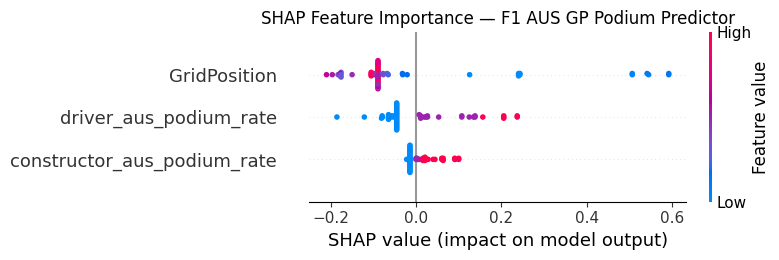

SHAP plot saved!


In [17]:
# SHAP tree explainer 
explainer = shap.TreeExplainer(rf_final)
shap_explanation = explainer(X)

# Generate summary plot using the new SHAP API
shap.summary_plot(shap_explanation[:,:,1], X, show=False)
plt.title('SHAP Feature Importance — F1 AUS GP Podium Predictor')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved!")

# Save calibrated model

In [19]:
# Save calibrated model for use in predictions notebook
with open('calibrated_rf_model.pkl', 'wb') as f:
    pickle.dump(calibrated_model, f)

# Save feature columns
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("Models saved successfully!")
print("Features:", list(X.columns))

Models saved successfully!
Features: ['GridPosition', 'driver_aus_podium_rate', 'constructor_aus_podium_rate']
